1)a)Apresente os parâmetros do modelo e o MSE (erro quadrático médio)
obtidos pelo algoritmo OLS (mínimos quadrados ordinários). Plote
a reta resultante sobre os dados.


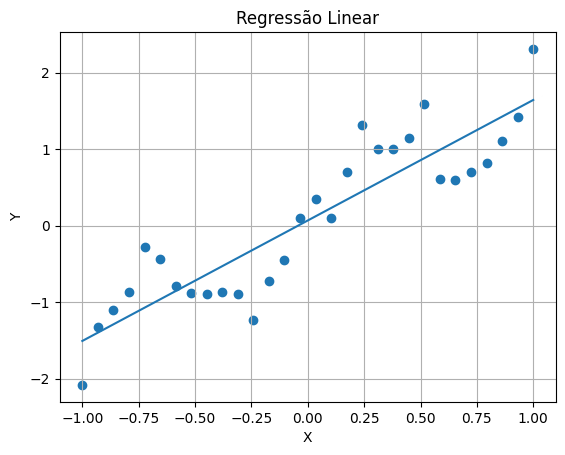

RMSE: 0.46195335406225796
w: [[0.06761792]
 [1.57486517]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# carregar dados
artificial1d_dataset = np.genfromtxt('./artificial1d.csv', delimiter=',')

# cria coluna de 1's
ones = np.ones((artificial1d_dataset.shape[0], 1))

X = np.hstack((ones, artificial1d_dataset[:, [0]]))

# saída
y = artificial1d_dataset[:, [1]]

# equação normal
X_t = X.T
w = X_t @ X
w = np.linalg.inv(w)
w = w @ X_t
w = w @ y

# predição
y_estimado = X @ w

# RMSE
RMSE = y - y_estimado
RMSE = RMSE**2
RMSE = np.mean(RMSE)
RMSE = np.sqrt(RMSE)

# ===== GRÁFICO =====
x = artificial1d_dataset[:, 0]
y_real = artificial1d_dataset[:, 1]
y_estimado = y_estimado.flatten()

# ordenar para linha correta
indices = np.argsort(x)

plt.scatter(x, y_real)
plt.plot(x[indices], y_estimado[indices])

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regressão Linear')
plt.grid()

plt.show()

# resultados
print("RMSE:", RMSE)
print("w:", w)

1)b) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem
obtidos pelo algoritmo GD (gradiente descendente). Plote a reta resultante sobre os dados.

In [13]:
import numpy as np

def normalizar_artificial1d():
    artificial1d_dataset = np.genfromtxt('./artificial1d.csv', delimiter=',')

    media = np.mean(artificial1d_dataset, axis=0)
    xi = artificial1d_dataset - media

    n = artificial1d_dataset.shape[0]
    var = np.sqrt(np.sum(xi**2, axis=0)/(n-1))

    xi_barra = xi / var

    return xi_barra
xi_barra = normalizar_artificial1d()
display(xi_barra)

def desnormalizar(valor_normalizado, media, desvio, coluna):
    return valor_normalizado * desvio[coluna] + media[coluna]


array([[-1.64708932, -2.01776249],
       [-1.53349695, -1.30904437],
       [-1.41990459, -1.10124292],
       [-1.30631222, -0.883802  ],
       [-1.19271985, -0.33101133],
       [-1.07912749, -0.4681726 ],
       [-0.96553512, -0.8094684 ],
       [-0.85194275, -0.89518064],
       [-0.73835038, -0.90816383],
       [-0.62475802, -0.87244232],
       [-0.51116565, -0.89704272],
       [-0.39757328, -1.22359975],
       [-0.28398092, -0.73889504],
       [-0.17038855, -0.48776262],
       [-0.05679618,  0.02936257],
       [ 0.05679618,  0.26409184],
       [ 0.17038855,  0.02802824],
       [ 0.28398092,  0.59377355],
       [ 0.39757328,  1.16664694],
       [ 0.51116565,  0.87685048],
       [ 0.62475802,  0.87817074],
       [ 0.73835038,  1.0151381 ],
       [ 0.85194275,  1.43105993],
       [ 0.96553512,  0.50825472],
       [ 1.07912749,  0.49448105],
       [ 1.19271985,  0.59641045],
       [ 1.30631222,  0.70934463],
       [ 1.41990459,  0.97511683],
       [ 1.53349695,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

artificial1d_dataset = np.genfromtxt('./artificial1d.csv', delimiter=',')

def RMSE(y_real, y_pred):
    erro = y_real - y_pred
    return np.sqrt(np.mean(erro**2))

# 🔹 calcula media e desvio ANTES
media = np.mean(artificial1d_dataset, axis=0)

xi = artificial1d_dataset - media
n = artificial1d_dataset.shape[0]
desvio = np.sqrt(np.sum(xi**2, axis=0)/(n-1))

# 🔹 agora normaliza
peixe_dataset = normalizar_peixe()

ones = np.ones((peixe_dataset.shape[0], 1))
X = np.hstack((ones, peixe_dataset[:, [0,1]]))
y = peixe_dataset[:, [2]]

a = 0.1
w = np.zeros((3, 1))
epocas = 100

erros = []

for i in range(epocas):
    y_pred = X @ w
    
    erro = y - y_pred
    
    grad = -2 * X.T @ erro / X.shape[0]
    
    w = w - a * grad

    y_pred_real = desnormalizar(y_pred, media, desvio, 2)
    y_real = artificial1d_dataset[:, [2]]

    erro_atual = RMSE(y_real, y_pred_real)
    
    erros.append(erro_atual)

# gráfico
plt.plot(erros)
plt.xlabel("Épocas")
plt.ylabel("RMSE")
plt.title("Curva de Aprendizado")
plt.show()